In [1]:
import sys, os
sys.path.insert(0, r'c:\Users\evinerskas\PycharmProjects\LAM_OOPAO')
print("CWD:", os.getcwd())

from OOPAO.Telescope import Telescope
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.calibration.CalibrationVault import CalibrationVault
from OOPAO.calibration.InteractionMatrix import InteractionMatrix
from OOPAO.MisRegistration import MisRegistration
import numpy as np
import pylab as plt
import torch

CWD: c:\Users\evinerskas\PycharmProjects\LAM_OOPAO\Examples


     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


OOPAO Warning: 
Significant changes were done to the OOPAO repository, the Telescope class is no longer the "master" class and the Source is now carrying the EM-field info.


In [2]:
ngs = Source(optBand='H', magnitude=0, display_properties=False)
tel = Telescope(resolution=90, diameter=1.52)
ngs ** tel
atm = Atmosphere(telescope= tel, r0 = 0.1, L0 = 25, windSpeed=[5], fractionalR0=[1], windDirection=[0], altitude=[0], src=ngs)

param = np.load('dm_second_stage_misreg_dict.npy', allow_pickle=True).item()
print(param)
m = MisRegistration(param)

dm = DeformableMirror(telescope = tel,
                        nSubap=10,
                        mechCoupling=0.35,
                        print_dm_properties=False,
                        pitch=0.11,
                        misReg = m,
                        sign=-1e-5) #influence function peak? (not found in OZIIRIS)


------------ Telescope -------------
Diameter [m]             |   1.52   
Resolution [px]          |    90    
Pixel size [m]           |   0.02   
Surface [m²]             |   1.82   
Central obstruction [%]  |    0     
Pixels in pupil          |   6376   
Field of view [arcsec]   |   0.00   
------------------------------------

{'rotationAngle': np.float64(-89.131), 'shiftX': np.float64(-0.011), 'shiftY': np.float64(-0.007), 'anamorphosisAngle': 0, 'tangentialScaling': np.float64(0.087), 'radialScaling': np.float64(0.093)}


In [3]:
param = np.load('dm_second_stage_misreg_dict.npy', allow_pickle=True).item()
m = MisRegistration(param)

dm = DeformableMirror(telescope = tel,
                        nSubap=10,
                        mechCoupling=0.35,
                        print_dm_properties=False,
                        pitch=0.11,
                        misReg = m,
                        sign=-1e-5)

M2C = np.load('M2C_KL.npy')

In [4]:
from Papyrus2ndStage import Papyrus2ndStage #the cnn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

cnn = Papyrus2ndStage().to(device = device)

checkpoint_path = 'OziNewDM2.pth' #cnn weights?
checkpoint = torch.load(checkpoint_path, map_location=torch.device(device))
cnn.load_state_dict(checkpoint['PhaseEstimator_state_dict'])


<All keys matched successfully>

In [5]:
from Frame_Preprocess import Frame_Preprocess

pupil_centers = np.array([[ 81, 128],
                          [175, 128]])

frame_preprocessor = Frame_Preprocess(pupil_centers)

(256, 256)
(256, 256)
(2, 92, 92)


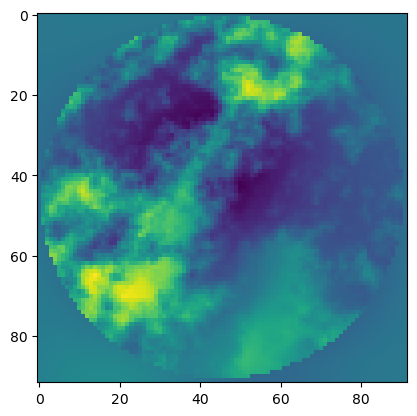

In [6]:
wfs_frames = np.load('wfs_frames.npy')
print(wfs_frames[0].shape)
reference_intensity = np.load('reference_intensity.npy')
frame_preprocessor.ProcessReference(reference_intensity)
print(frame_preprocessor.reference.shape)

pupils = frame_preprocessor.ProcessFrame(wfs_frames[0]) #pupils seem to be just the processed frames that I need to input into the CNN
print(pupils.shape)
plt.figure()
plt.imshow(pupils[0])
plt.show()

In [7]:
preprocessed_frames = np.load('preprocessed_frames.npy')
reference_intensity = np.load('reference_intensity.npy')
wfs_frames = np.load('wfs_frames.npy')
test_phase = np.load('Test_phase.npy')
print(preprocessed_frames.shape)
print(reference_intensity.shape)
print(wfs_frames.shape)
print(test_phase.shape)

(32, 2, 92, 92)
(256, 256)
(32, 256, 256)
(32, 90, 90)


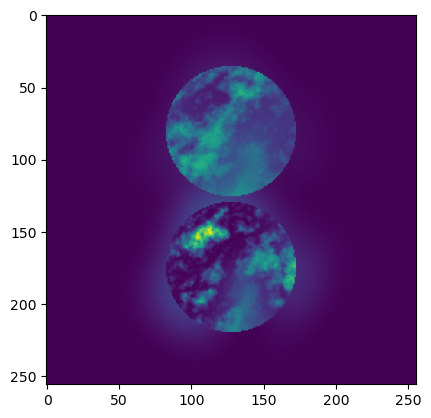

In [8]:
plt.figure()
plt.imshow(wfs_frames[0])
plt.show()
#TODO why are the wfs images 256x256?
#you don't really need this resolution, you can just recenter it based on Mathieu's zernike camera

(2, 92, 92)
torch.Size([1, 2, 92, 92])
(50,)
(97, 87)
(97,)


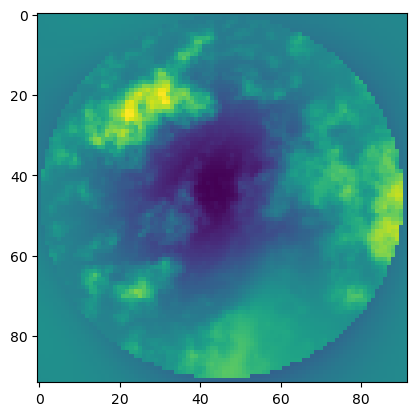

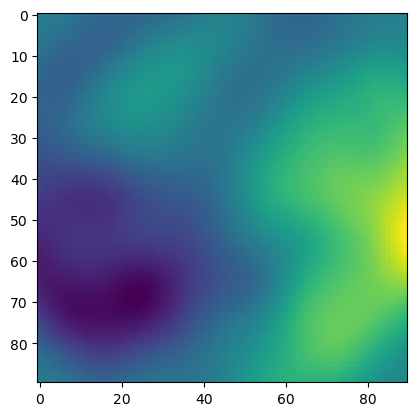

In [9]:
print(preprocessed_frames[0].shape)
cnn_input = torch.from_numpy(preprocessed_frames[0]).unsqueeze(0).float()
output = cnn(cnn_input).detach().cpu().numpy().squeeze()
print(cnn_input.shape)
print(output.shape)
print(M2C.shape)

phase_map = M2C[:, :50] @ output
dm.coefs = phase_map
print(phase_map.shape)
plt.figure()
plt.imshow(preprocessed_frames[0, 1])
plt.figure()
plt.imshow(dm.OPD)
plt.show()

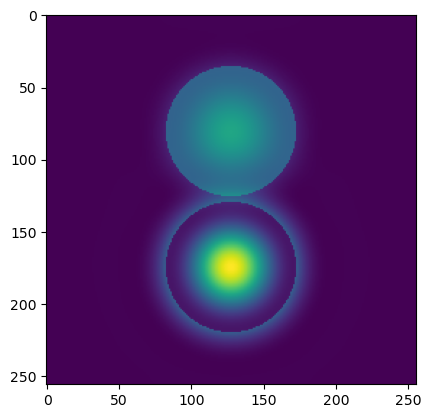

In [10]:
#TODO input 
plt.figure()
plt.imshow(reference_intensity)
plt.show()

In [15]:

print(reference_intensity.shape)
print(np.sum(reference_intensity))
print(wfs_frames[0].shape)
print(np.sum(wfs_frames[0]))
print(pupils[1].shape)
print(np.sum(pupils[1]))


(256, 256)
1.0
(256, 256)
1.0
(92, 92)
-1132.5813
